In [1]:
! git clone https://github.com/suyash1574/genai


Cloning into 'genai'...
remote: Enumerating objects: 9, done.
remote: Counting objects: 100% (9/9), done.
remote: Compressing objects: 100% (7/7), done.
remote: Total 9 (delta 0), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (9/9), 678.11 KiB | 9.55 MiB/s, done.


In [3]:
import tensorflow as tf

print('Eager Execution :' , tf.executing_eagerly())
a = tf.constant([[2,3],[5,6]])
b = tf.constant([[1,2],[3,4]])
matmultification = tf.matmul(a,b)
add=tf.add(a,b)
mul=tf.multiply(a,b)

print(matmultification)
print(add)
print(mul)

x=tf.Variable(5.0)
for i in range (3):
  x.assign_add(2.0)
  print(x.numpy())

Eager Execution : True
tf.Tensor(
[[11 16]
 [23 34]], shape=(2, 2), dtype=int32)
tf.Tensor(
[[ 3  5]
 [ 8 10]], shape=(2, 2), dtype=int32)
tf.Tensor(
[[ 2  6]
 [15 24]], shape=(2, 2), dtype=int32)
7.0
9.0
11.0


In [ ]:
import pandas as pd
import numpy as np

df = pd.read_csv("your_dataset.csv")

print("Original Data:\n", df.head())


df = df.fillna(df.mean(numeric_only=True))
df = df.fillna(df.mode().iloc[0])


from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
num_cols = df.select_dtypes(include=['float64', 'int64']).columns
df[num_cols] = scaler.fit_transform(df[num_cols])


from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
cat_cols = df.select_dtypes(include=['object']).columns
for col in cat_cols:
    df[col] = le.fit_transform(df[col])

print("\nCleaned and Encoded Data:\n", df.head())


In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

# Histogram for numeric features
df.hist(figsize=(8, 6))
plt.suptitle("Histogram of Features")
plt.show()

# Scatter plot between two numeric features (adjust columns)
plt.scatter(df[num_cols[0]], df[num_cols[1]], color='teal')
plt.title("Scatter Plot")
plt.xlabel(num_cols[0])
plt.ylabel(num_cols[1])
plt.show()

# Correlation heatmap
plt.figure(figsize=(6, 5))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()


NameError: name 'df' is not defined

In [5]:
!pip install -q faiss-cpu spacy
!python -m spacy download en_core_web_md

import faiss
import numpy as np
import spacy

nlp = spacy.load('en_core_web_md')

words = ['king', 'queen', 'man', 'woman', 'apple', 'orange']
vectors = np.array([nlp(w).vector for w in words]).astype('float32')

index = faiss.IndexFlatL2(vectors.shape[1])
index.add(vectors)

query_word = 'royal'
query_vec = np.array([nlp(query_word).vector], dtype='float32')

distances, indices = index.search(query_vec, k=3)

print(f"\nQuery: {query_word}")
for i in range(3):
    print(f"{i+1}. {words[indices[0][i]]} (distance: {distances[0][i]:.4f})")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 31.4/31.4 MB 46.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 33.5/33.5 MB 46.8 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_md')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.

Query: royal
1. queen (distance: 62.3108)
2. king (distance: 71.0804)
3. man (distance: 75.4891)


11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


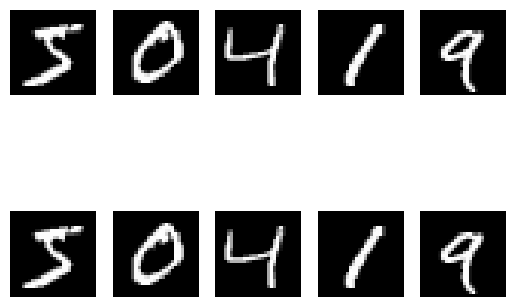

In [6]:
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import mnist

(x_train, _), _ = mnist.load_data()
x_train = x_train.astype("float32") / 255.0

# Add and remove simple Gaussian noise
noise = tf.random.normal(x_train[:5].shape, stddev=0.5)
noisy = x_train[:5] + noise
denoised = tf.clip_by_value(noisy - noise, 0, 1)

# Show results
for i in range(5):
    plt.subplot(2, 5, i+1)
    plt.imshow(x_train[i], cmap='gray')
    plt.axis('off')
    plt.subplot(2, 5, i+6)
    plt.imshow(denoised[i], cmap='gray')
    plt.axis('off')
plt.show()


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model_index.json:   0%|          | 0.00/616 [00:00<?, ?B/s]

Fetching 12 files:   0%|          | 0/12 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/855 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/618 [00:00<?, ?B/s]

...

config.json:   0%|          | 0.00/655 [00:00<?, ?B/s]

vae/diffusion_pytorch_model.safetensors:   0%|          | 0.00/335M [00:00<?, ?B/s]

Loading pipeline components...:   0%|          | 0/5 [00:00<?, ?it/s]

`torch_dtype` is deprecated! Use `dtype` instead!
You have disabled the safety checker for <class 'diffusers.pipelines.stable_diffusion.pipeline_stable_diffusion.StableDiffusionPipeline'> by passing `safety_checker=None`. Ensure that you abide to the conditions of the Stable Diffusion license and do not expose unfiltered results in services or applications open to the public. Both the diffusers team and Hugging Face strongly recommend to keep the safety filter enabled in all public facing circumstances, disabling it only for use-cases that involve analyzing network behavior or auditing its results. For more information, please have a look at https://github.com/huggingface/diffusers/pull/254 .


  0%|          | 0/4 [00:00<?, ?it/s]

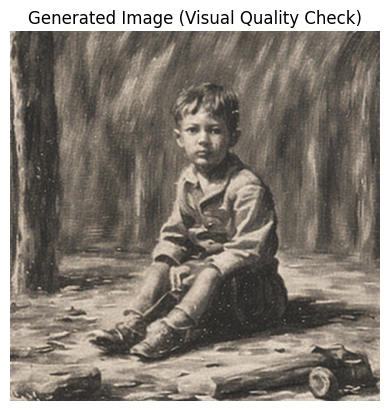

In [7]:
!pip install -q diffusers transformers accelerate torch torchvision

from diffusers import AutoPipelineForText2Image
import torch
import matplotlib.pyplot as plt

pipe = AutoPipelineForText2Image.from_pretrained(
    "stabilityai/sd-turbo",
    torch_dtype=torch.float32
)


prompt = "A small boy"
image = pipe(prompt, num_inference_steps=4, guidance_scale=0.0).images[0]


plt.imshow(image)
plt.axis("off")
plt.title("Generated Image (Visual Quality Check)")
plt.show()

In [8]:
!pip install -q transformers datasets

from transformers import AutoTokenizer, AutoModelForCausalLM, Trainer, TrainingArguments
from datasets import Dataset
import math, os

os.environ["WANDB_DISABLED"] = "true"

texts = [
    "AI is changing the world.",
    "Machine Learning learns from data.",
    "Generative AI creates art and text.",
    "NLP helps computers understand language."
]

data = Dataset.from_dict({"text": texts}).train_test_split(test_size=0.25)

tokenizer = AutoTokenizer.from_pretrained("distilgpt2")
tokenizer.pad_token = tokenizer.eos_token
model = AutoModelForCausalLM.from_pretrained("distilgpt2")

def tok(e):
    t = tokenizer(e["text"], truncation=True, padding="max_length", max_length=64)
    t["labels"] = t["input_ids"].copy()
    return t

tok_data = data.map(tok, batched=True)
tok_data.set_format("torch")

args = TrainingArguments(output_dir="out", num_train_epochs=1, per_device_train_batch_size=1, report_to="none")
trainer = Trainer(model=model, args=args, train_dataset=tok_data["train"], eval_dataset=tok_data["test"])
trainer.train()

text = "AI will"
out = model.generate(**tokenizer(text, return_tensors="pt"), max_new_tokens=30)
print("\nGenerated:", tokenizer.decode(out[0], skip_special_tokens=True))

res = trainer.evaluate()
print("Perplexity:", round(math.exp(res["eval_loss"]), 2))


tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/762 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/1.04M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

...

Step,Training Loss


Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.



Generated: AI will be a part of the future of the world.


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:666: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


Perplexity: 56.48


In [15]:
!pip install evaluate rouge_score
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM, pipeline
import evaluate

model_name = "facebook/bart-large-cnn"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForSeq2SeqLM.from_pretrained(model_name)

summarizer = pipeline("summarization", model=model, tokenizer=tokenizer)
qa_pipeline = pipeline("question-answering", model="distilbert-base-uncased-distilled-squad")

text_to_summarize = (
    "The Transformers library by Hugging Face provides state-of-the-art "
    "pre-trained models for NLP tasks. It allows you to easily use models "
    "for summarization, question answering, and more."
)

qa_context = text_to_summarize
qa_question = "What does the Transformers library provide?"

summary = summarizer(
    text_to_summarize, max_length=50, min_length=10, do_sample=False
)[0]['summary_text']

qa_answer = qa_pipeline(question=qa_question, context=qa_context)['answer']

print("Summary:", summary)
print("QA Answer:", qa_answer)

rouge = evaluate.load("rouge")

reference_summary = [
    "Hugging Face Transformers provides pre-trained NLP models for summarization and question answering."
]

rouge_score = rouge.compute(predictions=[summary], references=reference_summary)
print("ROUGE scores:", rouge_score)

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 1.8 MB/s eta 0:00:00
  Created wheel for rouge_score: filename=rouge_score-0.1.2-py3-none-any.whl size=24934 sha256=d9fbf55fe3c9158115eb33c737218bc5647109f23b03fde6cc4d74b9c13ba13f
  Stored in directory: /root/.cache/pip/wheels/85/9d/af/01feefbe7d55ef5468796f0c68225b6788e85d9d0a281e7a70
Successfully built rouge_score


config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

...

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

Device set to use cpu
Your max_length is set to 50, but your input_length is only 43. Since this is a summarization task, where outputs shorter than the input are typically wanted, you might consider decreasing max_length manually, e.g. summarizer('...', max_length=21)


Summary: The Transformers library by Hugging Face provides state-of-the-art pre-trained models for NLP tasks. It allows you to easily use models for summarization, question answering, and more.
QA Answer: state-of-the-art pre-trained models for NLP tasks


ROUGE scores: {'rouge1': np.float64(0.6046511627906976), 'rouge2': np.float64(0.2439024390243903), 'rougeL': np.float64(0.5116279069767441), 'rougeLsum': np.float64(0.5116279069767441)}


In [16]:
import faiss
import numpy as np
from sentence_transformers import SentenceTransformer
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM

docs = [
    "The Eiffel Tower is located in Paris, France.",
    "The Great Wall of China is one of the seven wonders of the world.",
    "Python is a popular programming language for machine learning.",
    "The Moon orbits the Earth approximately every 27 days.",
    "The Amazon rainforest produces 20% of the world's oxygen."
]

embedder = SentenceTransformer('all-MiniLM-L6-v2')
doc_embs = embedder.encode(docs, convert_to_numpy=True)

faiss.normalize_L2(doc_embs)
index = faiss.IndexFlatIP(doc_embs.shape[1])
index.add(doc_embs)

def retrieve(query, k=2):
    q_emb = embedder.encode([query], convert_to_numpy=True)
    faiss.normalize_L2(q_emb)
    D, I = index.search(q_emb, k)
    return [(docs[i], float(D[0][j])) for j, i in enumerate(I[0])]


tokenizer = AutoTokenizer.from_pretrained("google/flan-t5-small")
model = AutoModelForSeq2SeqLM.from_pretrained("google/flan-t5-small")

def rag_answer(query):
    results = retrieve(query, k=2)
    context = "\n".join([r[0] for r in results])
    prompt = f"Context:\n{context}\n\nQuestion: {query}\nAnswer:"
    inputs = tokenizer(prompt, return_tensors="pt", truncation=True)
    outputs = model.generate(**inputs, max_new_tokens=80)
    answer = tokenizer.decode(outputs[0], skip_special_tokens=True)
    return answer

query = "Where is the Eiffel Tower located?"
print("Q:", query)
print("A:", rag_answer(query))

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

special_tokens_map.json: 0.00B [00:00, ?B/s]

config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/308M [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/147 [00:00<?, ?B/s]

Q: Where is the Eiffel Tower located?
A: Paris, France


In [11]:
import torch, os
from transformers import DistilBertModel, DistilBertConfig

model = DistilBertModel(DistilBertConfig())
model.eval()
torch.save(model.state_dict(), "orig.pt")
orig_size = os.path.getsize("orig.pt")

qmodel = torch.quantization.quantize_dynamic(model, {torch.nn.Linear}, dtype=torch.qint8)
torch.save(qmodel.state_dict(), "quant.pt")
quant_size = os.path.getsize("quant.pt")
print("Original bytes:", orig_size, "Quantized bytes:", quant_size)

/tmp/ipython-input-3599253336.py:9: DeprecationWarning: torch.ao.quantization is deprecated and will be removed in 2.10. 
For migrations of users: 
1. Eager mode quantization (torch.ao.quantization.quantize, torch.ao.quantization.quantize_dynamic), please migrate to use torchao eager mode quantize_ API instead 
2. FX graph mode quantization (torch.ao.quantization.quantize_fx.prepare_fx,torch.ao.quantization.quantize_fx.convert_fx, please migrate to use torchao pt2e quantization API instead (prepare_pt2e, convert_pt2e) 
3. pt2e quantization has been migrated to torchao (https://github.com/pytorch/ao/tree/main/torchao/quantization/pt2e) 
see https://github.com/pytorch/ao/issues/2259 for more details
  qmodel = torch.quantization.quantize_dynamic(model, {torch.nn.Linear}, dtype=torch.qint8)


Original bytes: 265481849 Quantized bytes: 138107395


In [17]:
from transformers import pipeline

# load small pretrained text generator
gen = pipeline("text-generation", model="distilgpt2")

# prompts that may show bias
prompts = ["The nurse said", "The engineer said", "The teacher said"]

print("=== Raw Outputs ===")
for p in prompts:
    print(p, "->", gen(p, max_length=15, do_sample=True)[0]["generated_text"])

# simple bias mitigation: filter gendered words
def mitigate(text):
    banned = ["he", "she", "him", "her"]
    words = text.split()
    return " ".join([w for w in words if w.lower() not in banned])

print("\n=== Filtered Outputs ===")
for p in prompts:
    out = gen(p, max_length=15, do_sample=True)[0]["generated_text"]
    print(p, "->", mitigate(out))


Device set to use cpu
Truncation was not explicitly activated but `max_length` is provided a specific value, please use `truncation=True` to explicitly truncate examples to max length. Defaulting to 'longest_first' truncation strategy. If you encode pairs of sequences (GLUE-style) with the tokenizer you can select this strategy more precisely by providing a specific strategy to `truncation`.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Both `max_new_tokens` (=256) and `max_length`(=15) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


=== Raw Outputs ===


Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Both `max_new_tokens` (=256) and `max_length`(=15) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


The nurse said -> The nurse said it was a woman's mistake to say that she had been to the hospital for a day, and now it's her mistake to say that she has been to the hospital for a day.




"I've done my best to get a decent look at all the nurses at one of our hospitals, and I'm sure we'll learn the lessons of them," she said.
"They're a great team and they're all great.
"I don't think there's any doubt that we're going to be able to perform well.
"I'm very proud of them, and I'm very proud of them."


Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Both `max_new_tokens` (=256) and `max_length`(=15) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


...

The teacher said -> The teacher said there was no evidence that the teacher was teaching the school. She said she did not recall any of the children taking part in the class.





































































































































































































































=== Filtered Outputs ===


Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Both `max_new_tokens` (=256) and `max_length`(=15) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


The nurse said -> The nurse said the incident was not isolated and that was able to get out of the hospital. Topics: family-and-children, child-abuse, sydney-2000, united-states, australia First posted


Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Both `max_new_tokens` (=256) and `max_length`(=15) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


The engineer said -> The engineer said the team will use the "factory" to get the required materials, which are not required.
The teacher said -> The teacher said was shocked when first saw the pictures.


In [18]:
import random

class Agent:
    def __init__(self, name): self.name = name
    def act(self, context):
        if "food" in context: return f"{self.name}: Let's cook!"
        if "danger" in context: return f"{self.name}: Let's hide!"
        return f"{self.name}: Let's explore!"

agents = [Agent("Alpha"), Agent("Beta")]

# simple environment simulation
states = ["food nearby", "danger ahead", "nothing around"]
for step in range(3):
    context = random.choice(states)
    print(f"\nEnvironment: {context}")
    for a in agents:
        print(a.act(context))



Environment: nothing around
Alpha: Let's explore!
Beta: Let's explore!

Environment: food nearby
Alpha: Let's cook!
Beta: Let's cook!

Environment: food nearby
Alpha: Let's cook!
Beta: Let's cook!
